## Task 2: Building a Simple Baseline Model

In this task, you will build and train a classification model from scratch. This will serve as your baseline model against which you can compare results. Create a Jupyter notebook named `baseline.ipynb`, which implements the following steps (you can import the dataset loading from previous steps into this notebook):

> **Hint:** If your initial training runs result in poor accuracy on the test set, find out why this is the case based on the observations made in Task 1. Carefully reconsider your training and final evaluation strategy to address this problem. In particular, reflect on the implementation of the loss function. A conventional loss may not sufficiently penalize misclassifications. Additionally, you can think about complementary strategies.

> **Hint:** Some loss functions have a built-in activation function. In these cases, you do not need a final activation layer in your network. However, when validating the model, you should then apply the activation to your outputs before performing the classification.

### 1. Set up the classification
- Choose one or more metrics to evaluate the success of your classifier.

### 2. Build your initial model
- Build a classifier model with a convolutional part followed by a fully connected part. The convolutional part must have convolutional layers, but you can also include activation, pooling, or batch normalization layers.
- The fully connected part must have fully connected layers and one or more dropout layers.
- Print the initial architecture.
- Print the number of trainable parameters.

### 3. Train your model
- Choose a good loss function for training the model and reasonable starting hyperparameter values.
- Decide which performance metric(s) you will use to evaluate the model and briefly justify your choice.
- Train your initial model on the dataset while monitoring the performance on the validation set.
- Ensure that the model runs without errors and that the training loss decreases smoothly.
- Plot the model history containing its performance at each epoch for both the training and validation sets.

### 4. Hyperparameter tuning
- Typically, hyperparameter tuning is performed. As this requires training multiple models, which is time-consuming, you do not have to complete a full tuning procedure. Nevertheless, make smart choices for your hyperparameters. Furthermore, you can also test different loss functions or optimizers.

### 5. Your final baseline
- Retrain your model using the complete training dataset (including the validation set) with the previously determined optimal set of hyperparameters.
- Plot the training curve.
- Save the model and load it again.
- Evaluate the model on the test dataset and report the performance metric(s) chosen for this problem.
- Plot a few samples from the test dataset (without normalization) together with their predictions and ground-truth labels.
- Perform a ROC–AUC analysis and plot the ROC curve.
- Based on the ROC curve, discuss which classification threshold you would choose and justify your choice.
- Display the confusion matrix based on the considered decision threshold.
- Reflect on the clinical implications of this threshold choice (e.g., prioritizing sensitivity vs. specificity).

---

Discuss the implementation of the baseline model in your report. Include the following:

- **Model architecture:** Describe and discuss your model architecture.
- **Metrics:** Which metrics did you use to evaluate the model? Why are these appropriate, and how do you interpret them based on your results? Also consider the clinical interpretation of the chosen metrics.
- **Training and validation loss:** Which loss function did you choose and why? What conclusions can you draw from the loss curves? Did you observe signs of overfitting? If so, which countermeasures against overfitting did you take or would you suggest?
- **Hint:** If you made any changes based on the hint above, include and motivate them in the sections below.
- **Hyperparameters:** Discuss the chosen hyperparameters.
- **Others:** If you carried out further optimization or experiments, you may include them here as well. For example, did you try other loss functions?
- **Performance:** What conclusions can you draw from the performance on the test set? How does the chosen decision threshold affect the clinical interpretation of the model's predictions?

# 0. Setup

In [2]:
# Set the GPU device
import sys

sys.path.insert(0, "../0_generalcode")
from gpu_helper import settest_torch_gpu

device = settest_torch_gpu()

PyTorch CUDA available: True
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
Prediction shape: (5, 1)  — running on device: cuda


In [ ]:
import itertools
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR
from torch.utils.data import DataLoader, ConcatDataset, Subset
from torchvision import datasets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
)
from sklearn.model_selection import StratifiedKFold
import os
from datetime import datetime


from pipeline_helper import (
    MyTransform,
    MyPreprocess,
    MyToTensor,
    g_train_mean,
    g_train_std,
    g_train_no_outliers_mean,
    g_train_no_outliers_std,
)
from img_helper import show_images

In [ ]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

# 1. Introduction

In this notebook we build and evaluate a baseline CNN for binary knee OA classification. We compare two training variants:

- **Variant A**: BaselineCNN trained on the **full** training set (including outliers)
- **Variant B**: BaselineCNN trained on the **outlier-filtered** training set (outliers identified in preprocessing)

**Metric strategy:**
- **Hyperparameter selection** uses **validation loss**, it reflects overall model calibration without being biased toward a single operating point.
- **Variant A vs B selection** uses **recall as primary criterion, with AUC as tiebreaker** in a medical screening context, missing an OA case (false negative) is more harmful than a false alarm (false positive). A false negative means a patient goes undiagnosed and potentially untreated, whereas a false positive leads to further investigation but no direct harm.
- **Threshold analysis** uses **recall** thresholds are adjusted to achieve ≥95% sensitivity. Initial evaluation (Sections 5.3 and 6.3) reports metrics at the default threshold of 0.5; the 95% recall threshold is determined in Section 8.

Accuracy and F1 score are reported alongside for completeness.


# 2. Data Preparation

In [ ]:
DATA_DIR = "../../data/1_source/"

# Variant A: full training set with default normalization stats
train_dataset = datasets.ImageFolder(DATA_DIR + "train", transform=MyTransform())
val_dataset = datasets.ImageFolder(DATA_DIR + "val", transform=MyPreprocess())
test_dataset = datasets.ImageFolder(DATA_DIR + "test", transform=MyPreprocess())

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {train_dataset.classes}")

Training samples: 750
Validation samples: 159
Test samples: 146
Classes: ['0', '1']


In [ ]:
# Build combined datasets for 5-fold cross-validation on Variant A.
# We load the train directory twice:
#   - with MyTransform() for train folds (augmentation)
#   - with MyPreprocess() for val folds and stratification labels (no augmentation)
train_dataset_base = datasets.ImageFolder(DATA_DIR + "train", transform=MyPreprocess())

combined_aug = ConcatDataset(
    [train_dataset, val_dataset]
)  # augmented train + clean val
combined_base = ConcatDataset(
    [train_dataset_base, val_dataset]
)  # clean train  + clean val

# Labels list for StratifiedKFold (preserves class balance in each fold)
combined_labels = train_dataset_base.targets + val_dataset.targets

print(f"Combined CV dataset size: {len(combined_base)}")
print(
    f"Class distribution — Healthy: {combined_labels.count(0)}, OA: {combined_labels.count(1)}"
)

Combined CV dataset size: 909
Class distribution — Healthy: 596, OA: 313


### Outlier-filtered dataset (Variant B)

We drop the outlier images identified during preprocessing and use the corresponding normalization statistics.

In [ ]:
images_info = pd.read_csv(DATA_DIR + "/images_info.csv")


def make_filtered_dataset(root, split, transform, info_df, drop_col="drop_sample"):
    """Return an ImageFolder for split, keeping only rows where drop_col == 0."""
    ds = datasets.ImageFolder(os.path.join(root, split), transform=transform)
    keep = set(
        info_df[(info_df["split"] == split) & (info_df[drop_col] == 0)]["filename"]
    )
    valid_idx = [
        i for i, (path, _) in enumerate(ds.samples) if os.path.basename(path) in keep
    ]
    return Subset(ds, valid_idx)


# Variant B datasets: no-outlier stats for normalization
train_no_outlier_dataset = make_filtered_dataset(
    DATA_DIR,
    "train",
    MyTransform(tr_mean=g_train_no_outliers_mean, tr_std=g_train_no_outliers_std),
    images_info,
)
val_no_outlier_dataset = datasets.ImageFolder(
    DATA_DIR + "val",
    transform=MyPreprocess(
        tr_mean=g_train_no_outliers_mean, tr_std=g_train_no_outliers_std
    ),
)
test_no_outlier_dataset = datasets.ImageFolder(
    DATA_DIR + "test",
    transform=MyPreprocess(
        tr_mean=g_train_no_outliers_mean, tr_std=g_train_no_outliers_std
    ),
)

train_no_outlier_loader = DataLoader(
    train_no_outlier_dataset, batch_size=32, shuffle=True
)
val_no_outlier_loader = DataLoader(val_no_outlier_dataset, batch_size=32, shuffle=False)
test_no_outlier_loader = DataLoader(
    test_no_outlier_dataset, batch_size=32, shuffle=False
)

print(f"Original train   : {len(train_dataset)} samples")
print(f"No-outlier train : {len(train_no_outlier_dataset)} samples")
print(
    f"Removed          : {len(train_dataset) - len(train_no_outlier_dataset)} sample(s)"
)

Original train   : 750 samples
No-outlier train : 742 samples
Removed          : 8 sample(s)


In [ ]:
# Class balance
class_counts = np.bincount([label for _, label in train_dataset])
print(
    f"Healthy: {class_counts[0]}, OA: {class_counts[1]}, ratio: {class_counts[0]/class_counts[1]:.2f}"
)

# pos_weight for Variant A: penalise missed OA cases proportionally to class imbalance
pos_weight_A = torch.tensor(
    [class_counts[0] / class_counts[1]], dtype=torch.float32
).to(device)
print(f"pos_weight_A = {pos_weight_A.item():.4f}")

Healthy: 500, OA: 250, ratio: 2.00
pos_weight_A = 2.0000


# 3. Model Architecture

In [ ]:
class BaselineCNN(nn.Module):
    def __init__(
        self,
        num_conv_layers=3,
        base_filters=32,
        kernel_size=3,
        dropout_rate=0.3,
        use_1x1=False,
    ):
        super().__init__()
        padding = kernel_size // 2  # maintain spatial size before each max pool

        # Convolutional part: build blocks dynamically
        layers = []
        in_channels = 1
        for i in range(num_conv_layers):
            out_channels = base_filters * (2**i)
            layers += [
                nn.Conv2d(
                    in_channels, out_channels, kernel_size=kernel_size, padding=padding
                ),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
                nn.MaxPool2d(2),
            ]
            in_channels = out_channels
        self.conv_block = nn.Sequential(*layers)

        # Optional 1×1 projection to 2048 channels (matches ResNet50 feature dimensions)
        if use_1x1:
            self.proj = nn.Sequential(
                nn.Conv2d(in_channels, 2048, kernel_size=1),
                nn.BatchNorm2d(2048),
                nn.ReLU(),
            )
            fc_in = 2048
        else:
            self.proj = None
            fc_in = in_channels

        self.pool = nn.AdaptiveAvgPool2d(1)

        # Fully connected part — input size adapts to last conv block's output channels
        self.fc_block = nn.Sequential(
            nn.Flatten(),
            nn.Linear(fc_in, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        x = self.conv_block(x)
        if self.proj is not None:
            x = self.proj(x)
        x = self.pool(x)
        return self.fc_block(x)


# Print architecture and parameter count
model = BaselineCNN(
    num_conv_layers=3, base_filters=32, kernel_size=3, dropout_rate=0.3, use_1x1=False
).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters (use_1x1=False): {total_params:,}")

model_1x1 = BaselineCNN(
    num_conv_layers=3, base_filters=32, kernel_size=3, dropout_rate=0.3, use_1x1=True
).to(device)
total_params_1x1 = sum(p.numel() for p in model_1x1.parameters() if p.requires_grad)
print(f"Trainable parameters (use_1x1=True):  {total_params_1x1:,}")

BaselineCNN(
  (conv_block): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=1)
  (fc_block): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=128

# 4. Training & Evaluation Infrastructure

In [ ]:
def train_model(
    model,
    train_loader,
    val_loader,
    criteria,
    optimizer,
    num_epochs,
    device,
    scheduler=None,
):
    """Train the model and track loss, accuracy, recall, F1, and gradient norm per epoch."""
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "train_recall": [],
        "val_recall": [],
        "train_f1": [],
        "val_f1": [],
        "grad_norm": [],
    }

    for epoch in range(num_epochs):
        # --- Training phase ---
        model.train()
        running_loss = 0.0
        all_preds, all_labels = [], []
        batch_grad_norms = []

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.float().to(device)

            optimizer.zero_grad()
            outputs = model(images).squeeze(1)
            loss = criteria(outputs, labels)
            loss.backward()

            # Compute total gradient norm across all parameters
            total_norm = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    total_norm += p.grad.detach().norm(2).item() ** 2
            batch_grad_norms.append(total_norm**0.5)

            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) >= 0.5).int()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = accuracy_score(all_labels, all_preds)
        train_recall = recall_score(all_labels, all_preds, zero_division=0)
        train_f1 = f1_score(all_labels, all_preds, zero_division=0)
        epoch_grad_norm = np.mean(batch_grad_norms)

        # --- Validation phase ---
        model.eval()
        running_loss = 0.0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.float().to(device)
                outputs = model(images).squeeze(1)
                loss = criteria(outputs, labels)

                running_loss += loss.item() * images.size(0)
                preds = (torch.sigmoid(outputs) >= 0.5).int()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss = running_loss / len(val_loader.dataset)
        val_acc = accuracy_score(all_labels, all_preds)
        val_recall = recall_score(all_labels, all_preds, zero_division=0)
        val_f1 = f1_score(all_labels, all_preds, zero_division=0)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_recall"].append(train_recall)
        history["val_recall"].append(val_recall)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)
        history["grad_norm"].append(epoch_grad_norm)

        if scheduler is not None:
            scheduler.step()

        if (epoch + 1) % 5 == 0:
            print(
                f"Epoch {epoch+1}/{num_epochs} | "
                f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, Recall: {train_recall:.4f}, F1: {train_f1:.4f} | "
                f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f} | "
                f"Grad Norm: {epoch_grad_norm:.4f}"
            )

    return history

In [ ]:
def plot_kfold_curves(fold_metrics, title="K-Fold Validation Curves", show_std=True):
    """Plot per-epoch val_loss, val_acc, val_f1 across folds.
    Thin semi-transparent lines per fold; thick mean line; optional ±std shaded band.
    """
    metrics = ["val_loss", "val_acc", "val_f1"]
    labels = ["Val Loss", "Val Accuracy", "Val F1"]
    colors = ["steelblue", "orange", "green"]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(title)

    for ax, key, label, color in zip(axes, metrics, labels, colors):
        arrays = np.array(
            [m["history"][key] for m in fold_metrics]
        )  # (n_folds, n_epochs)
        epochs = np.arange(1, arrays.shape[1] + 1)
        mean = arrays.mean(axis=0)
        std = arrays.std(axis=0)

        for i, fold_arr in enumerate(arrays):
            ax.plot(
                epochs,
                fold_arr,
                color=color,
                alpha=0.25,
                linewidth=1,
                label=f"Fold {i+1}" if i == 0 else "_",
            )

        ax.plot(epochs, mean, color=color, linewidth=2.5, label="Mean")

        if show_std:
            ax.fill_between(
                epochs, mean - std, mean + std, color=color, alpha=0.15, label="±1 std"
            )

        ax.set_xlabel("Epoch")
        ax.set_ylabel(label)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_history(history, title="Training History"):
    has_grad = "grad_norm" in history and len(history["grad_norm"]) > 0
    n_plots = 5 if has_grad else 4
    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4))

    axes[0].plot(history["train_loss"], label="Train")
    axes[0].plot(history["val_loss"], label="Validation")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Loss Curves")
    axes[0].legend()

    axes[1].plot(history["train_acc"], label="Train")
    axes[1].plot(history["val_acc"], label="Validation")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Accuracy Curves")
    axes[1].legend()

    axes[2].plot(history["train_recall"], label="Train")
    axes[2].plot(history["val_recall"], label="Validation")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Recall")
    axes[2].set_title("Recall Curves")
    axes[2].legend()

    axes[3].plot(history["train_f1"], label="Train")
    axes[3].plot(history["val_f1"], label="Validation")
    axes[3].set_xlabel("Epoch")
    axes[3].set_ylabel("F1 Score")
    axes[3].set_title("F1 Score Curves")
    axes[3].legend()

    if has_grad:
        axes[4].plot(history["grad_norm"], label="Grad Norm", color="tab:purple")
        axes[4].set_xlabel("Epoch")
        axes[4].set_ylabel("Gradient Norm (L2)")
        axes[4].set_title("Gradient Norm")
        axes[4].legend()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

In [ ]:
def select_threshold_by_recall(fpr, tpr, thresholds, min_recall=0.95):
    """
    Select the classification threshold that achieves at least `min_recall`
    (sensitivity) while keeping the false positive rate as low as possible.

    In a medical screening context we want to catch as many true OA cases as
    possible (high recall), accepting some false positives as a trade-off.
    """
    candidates = np.where(tpr >= min_recall)[0]
    if len(candidates) > 0:
        best_idx = candidates[np.argmin(fpr[candidates])]
    else:
        best_idx = np.argmax(tpr)
    return thresholds[best_idx], best_idx

In [ ]:
def evaluate_model(model, test_loader, device, variant_name="", threshold=0.50):
    """Run inference on test set and return probabilities, labels, and evaluation results."""
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images).squeeze(1)
            probs = torch.sigmoid(outputs)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    # ROC and AUC
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    roc_auc = roc_auc_score(all_labels, all_probs)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate (Recall)")
    plt.title(f"ROC Curve — {variant_name}")
    plt.legend()
    plt.show()

    # Predictions at chosen threshold
    final_preds = (all_probs >= threshold).astype(int)

    cm = confusion_matrix(all_labels, final_preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Healthy", "OA"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix — {variant_name} (threshold={threshold:.2f})")
    plt.show()

    acc = accuracy_score(all_labels, final_preds)
    f1 = f1_score(all_labels, final_preds)
    rec = recall_score(all_labels, final_preds)
    prec = precision_score(all_labels, final_preds, zero_division=0)

    print(f"\nTest Metrics ({variant_name}) at threshold={threshold:.2f}:")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1 Score : {f1:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  Precision: {prec:.4f}")

    return {
        "all_probs": all_probs,
        "all_labels": all_labels,
        "final_preds": final_preds,
        "threshold": threshold,
        "auc": roc_auc,
        "accuracy": acc,
        "f1": f1,
        "recall": rec,
        "precision": prec,
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
    }

# 5. Variant A: BaselineCNN with all training data

## 5.1 Architecture Search (5-Fold Cross-Validation)

Grid search over the model's **structural dimensions** using 5-fold stratified cross-validation. Hyperparameters (lr, dropout, weight_decay) are fixed for this phase. Best architecture is selected by **mean validation loss** (lower is better).

| Axis | Options |
|------|---------|
| `num_conv_layers` | 1, 2, 3 |
| `base_filters` | 32, 64 |
| `kernel_size` | 3, 5 |
| `use_1x1` | True, False |

Total: **24 configurations × 5 folds × 100 epochs**

In [ ]:
# ── Phase 1: Architecture Search ─────────────────────────────────────────────
# Hyperparameters are fixed; only model dimensions are varied.
ARCH_FIXED_LR = 1e-3
ARCH_FIXED_DROPOUT = 0.3
ARCH_FIXED_WEIGHT_DECAY = 1e-4

arch_grid = {
    "num_conv_layers": [1, 2, 3],
    "base_filters": [32, 64],
    "kernel_size": [3, 5],
    "use_1x1": [True, False],
}

arch_configs = [
    dict(zip(arch_grid.keys(), combo))
    for combo in itertools.product(*arch_grid.values())
]

num_epochs_arch = 100
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

arch_results_A = []

for config in arch_configs:
    print(
        f"\n--- Arch: layers={config['num_conv_layers']}, filters={config['base_filters']}, "
        f"kernel={config['kernel_size']}, use_1x1={config['use_1x1']} ---"
    )
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(
        skf.split(range(len(combined_base)), combined_labels)
    ):
        print(f"  Fold {fold + 1}/{N_FOLDS}...", end=" ", flush=True)

        fold_train_loader = DataLoader(
            Subset(combined_aug, train_idx), batch_size=32, shuffle=True
        )
        fold_val_loader = DataLoader(
            Subset(combined_base, val_idx), batch_size=32, shuffle=False
        )

        model = BaselineCNN(
            num_conv_layers=config["num_conv_layers"],
            base_filters=config["base_filters"],
            kernel_size=config["kernel_size"],
            dropout_rate=ARCH_FIXED_DROPOUT,
            use_1x1=config["use_1x1"],
        ).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_A)
        optimizer = optim.AdamW(
            model.parameters(), lr=ARCH_FIXED_LR, weight_decay=ARCH_FIXED_WEIGHT_DECAY
        )
        warmup = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=5)
        cosine = CosineAnnealingLR(optimizer, T_max=num_epochs_arch - 5, eta_min=1e-6)
        scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[5])

        history = train_model(
            model,
            fold_train_loader,
            fold_val_loader,
            criterion,
            optimizer,
            num_epochs=num_epochs_arch,
            device=device,
            scheduler=scheduler,
        )

        fold_metrics.append(
            {
                "val_loss": history["val_loss"][-1],
                "recall": history["val_recall"][-1],
                "f1": history["val_f1"][-1],
                "history": history,
            }
        )
        print(
            f"val_loss={fold_metrics[-1]['val_loss']:.4f}, recall={fold_metrics[-1]['recall']:.3f}"
        )

    arch_results_A.append(
        {
            **config,
            "mean_val_loss": np.mean([m["val_loss"] for m in fold_metrics]),
            "std_val_loss": np.std([m["val_loss"] for m in fold_metrics]),
            "mean_recall": np.mean([m["recall"] for m in fold_metrics]),
            "mean_f1": np.mean([m["f1"] for m in fold_metrics]),
            "fold_metrics": fold_metrics,
        }
    )
    print(
        f"  => mean val_loss={arch_results_A[-1]['mean_val_loss']:.4f} ± "
        f"{arch_results_A[-1]['std_val_loss']:.4f}"
    )

# Select best architecture: lowest mean 5-fold validation loss
_arch_keys = ["num_conv_layers", "base_filters", "kernel_size", "use_1x1"]
best_arch_result_A = min(arch_results_A, key=lambda r: r["mean_val_loss"])
best_arch_A = {k: best_arch_result_A[k] for k in _arch_keys}

print(f"\nBest architecture (Variant A): {best_arch_A}")
print(
    f"  mean val_loss = {best_arch_result_A['mean_val_loss']:.4f} ± "
    f"{best_arch_result_A['std_val_loss']:.4f}"
)


--- Arch: layers=1, filters=32, kernel=3, use_1x1=True ---
  Fold 1/5... Epoch 5/100 | Train Loss: 0.9382, Acc: 0.5241, Recall: 0.4064, F1: 0.3709 | Val Loss: 0.9262, Acc: 0.4066, Recall: 0.8226, F1: 0.4857 | Grad Norm: 1.3953
Epoch 10/100 | Train Loss: 0.9208, Acc: 0.5887, Recall: 0.4900, F1: 0.4514 | Val Loss: 0.9223, Acc: 0.4670, Recall: 0.7903, F1: 0.5026 | Grad Norm: 0.5946
Epoch 15/100 | Train Loss: 0.9195, Acc: 0.6190, Recall: 0.4104, F1: 0.4265 | Val Loss: 0.9192, Acc: 0.4835, Recall: 0.7581, F1: 0.5000 | Grad Norm: 0.8751
Epoch 20/100 | Train Loss: 0.9132, Acc: 0.5736, Recall: 0.5259, F1: 0.4599 | Val Loss: 0.9190, Acc: 0.4780, Recall: 0.7258, F1: 0.4865 | Grad Norm: 1.0903
Epoch 25/100 | Train Loss: 0.9047, Acc: 0.5832, Recall: 0.5100, F1: 0.4580 | Val Loss: 0.9134, Acc: 0.5330, Recall: 0.7581, F1: 0.5251 | Grad Norm: 0.8264
Epoch 30/100 | Train Loss: 0.9122, Acc: 0.6011, Recall: 0.4582, F1: 0.4423 | Val Loss: 0.9129, Acc: 0.6099, Recall: 0.4839, F1: 0.4580 | Grad Norm: 1.14

In [ ]:
# Architecture search results — sorted by mean val_loss ascending
_arch_keys = ["num_conv_layers", "base_filters", "kernel_size", "use_1x1"]
df_arch_cv = (
    pd.DataFrame(
        [
            {
                **{k: r[k] for k in _arch_keys},
                "mean_val_loss": r["mean_val_loss"],
                "std_val_loss": r["std_val_loss"],
                "mean_recall": r["mean_recall"],
                "mean_f1": r["mean_f1"],
                "best": all(r[k] == best_arch_A[k] for k in _arch_keys),
            }
            for r in arch_results_A
        ]
    )
    .sort_values("mean_val_loss", ascending=True)
    .reset_index(drop=True)
)
df_arch_cv.index += 1


def _highlight_best(row):
    return [
        "font-weight: bold; background-color: #d4edda" if row["best"] else ""
        for _ in row
    ]


display(
    df_arch_cv.style.apply(_highlight_best, axis=1)
    .format(
        {
            "mean_val_loss": "{:.4f}",
            "std_val_loss": "±{:.4f}",
            "mean_recall": "{:.3f}",
            "mean_f1": "{:.3f}",
        }
    )
    .set_caption(
        "Architecture Search — 5-Fold CV val_loss (lower is better, ★ = selected)"
    )
)

print(
    f"\nSelected: layers={best_arch_A['num_conv_layers']}, filters={best_arch_A['base_filters']}, "
    f"kernel={best_arch_A['kernel_size']}, use_1x1={best_arch_A['use_1x1']}  "
    f"(mean val_loss={best_arch_result_A['mean_val_loss']:.4f} ± {best_arch_result_A['std_val_loss']:.4f})"
)

,num_conv_layers,base_filters,kernel_size,use_1x1,mean_val_loss,std_val_loss,mean_recall,mean_f1,best
1,3,64,5,True,0.2357,±0.1434,0.936,0.922,True
2,3,32,5,True,0.2572,±0.1117,0.930,0.909,False
3,3,32,3,True,0.2936,±0.1265,0.923,0.899,False
4,3,64,3,True,0.3011,±0.1186,0.923,0.904,False
5,3,64,5,False,0.3065,±0.1088,0.930,0.887,False
6,3,32,5,False,0.3149,±0.0955,0.933,0.876,False
7,3,64,3,False,0.4001,±0.0710,0.898,0.845,False
8,3,32,3,False,0.4214,±0.0491,0.872,0.817,False
9,2,64,5,True,0.5032,±0.0683,0.869,0.797,False
10,2,32,5,True,0.5320,±0.0541,0.856,0.788,False



Selected: layers=3, filters=64, kernel=5, use_1x1=True  (mean val_loss=0.2357 ± 0.1434)


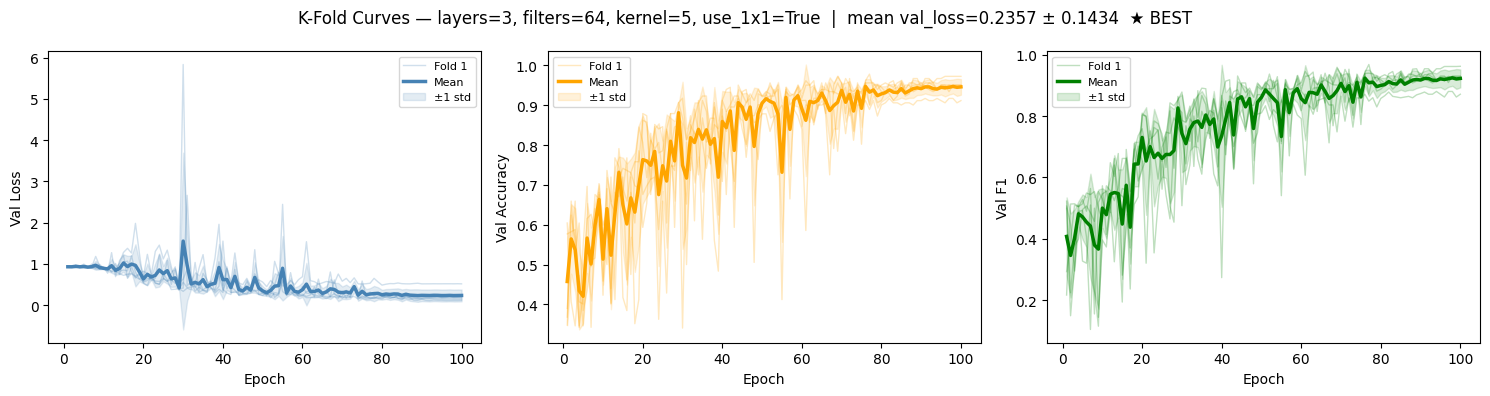

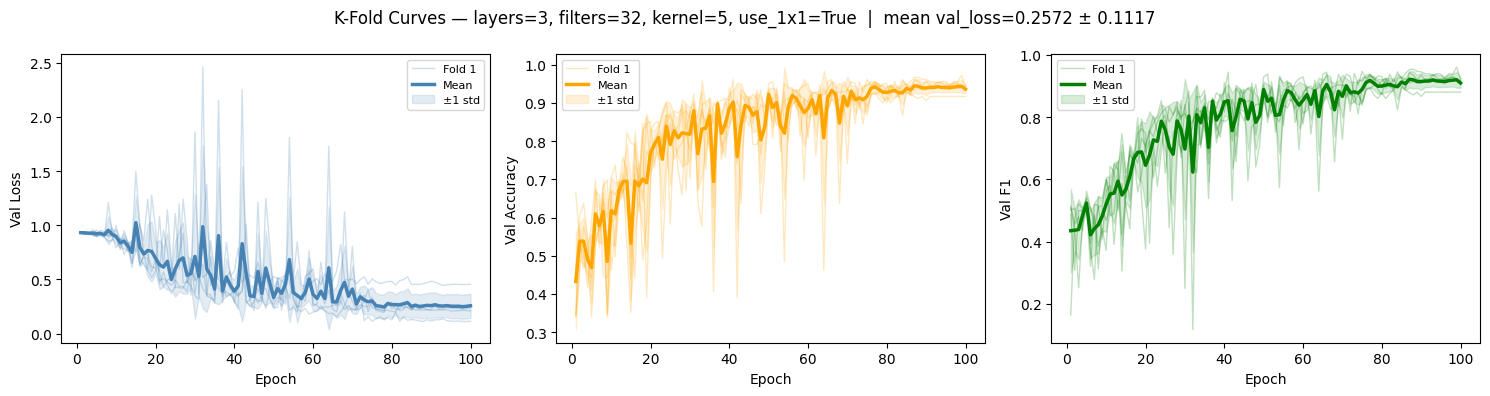

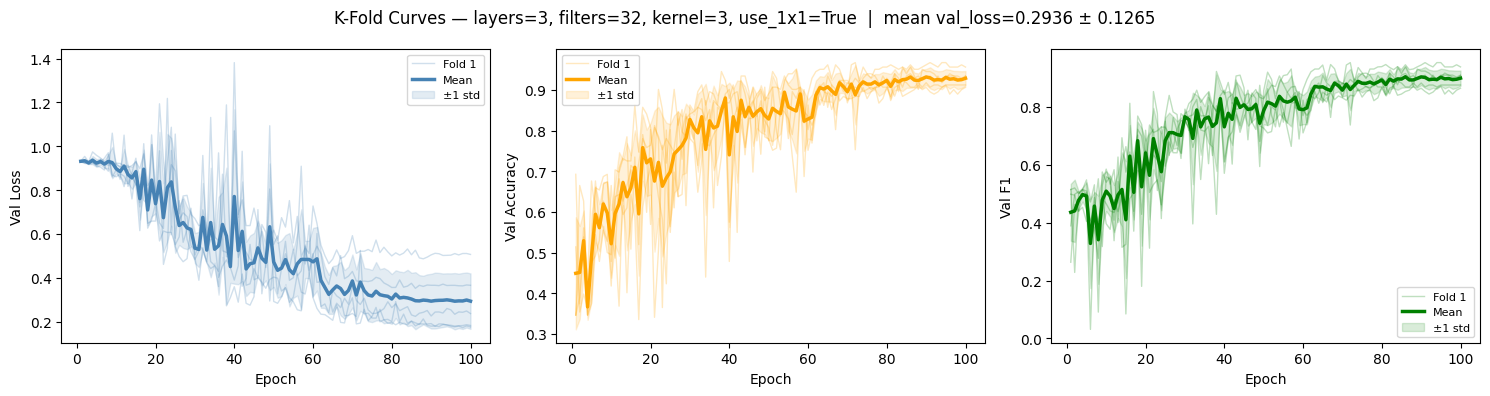

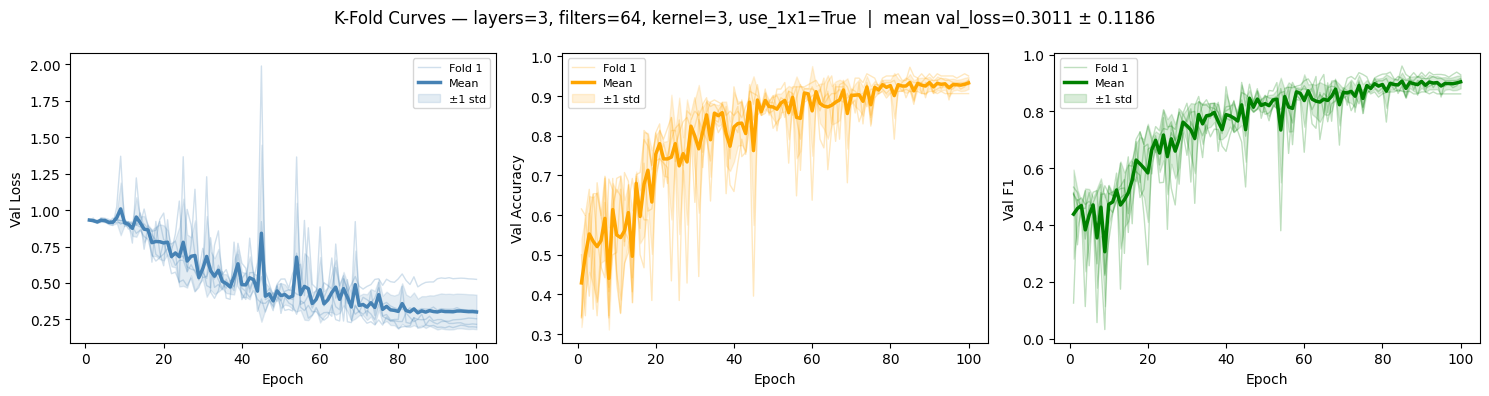

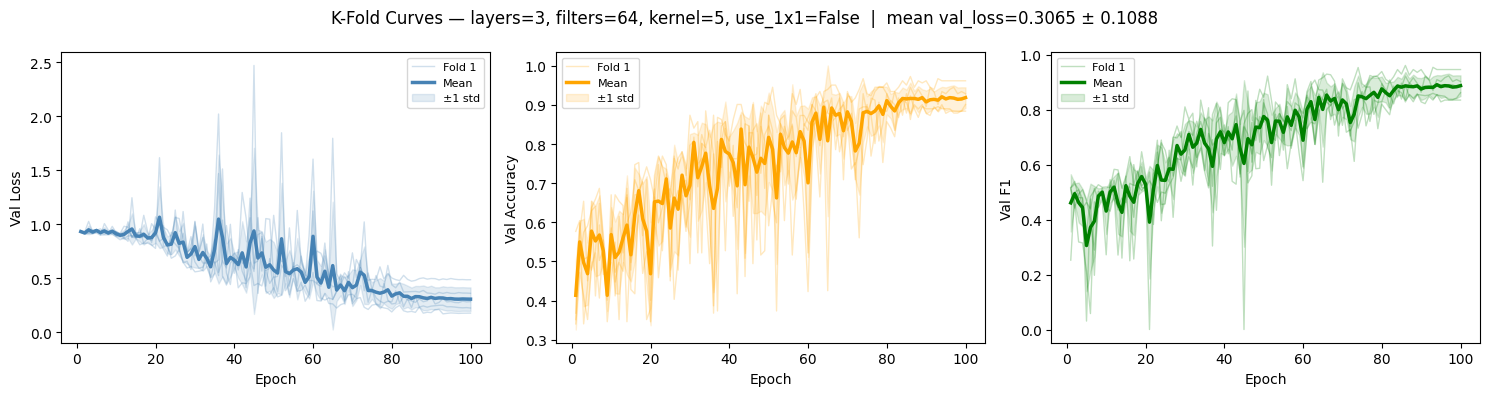

In [ ]:
# K-Fold validation curves — top 5 architectures by mean val_loss
_arch_keys = ["num_conv_layers", "base_filters", "kernel_size", "use_1x1"]
_top5_arch = sorted(arch_results_A, key=lambda r: r["mean_val_loss"])[:5]

for r in _top5_arch:
    is_best = all(r[k] == best_arch_A[k] for k in _arch_keys)
    title = (
        f"K-Fold Curves — layers={r['num_conv_layers']}, filters={r['base_filters']}, "
        f"kernel={r['kernel_size']}, use_1x1={r['use_1x1']}  |  "
        f"mean val_loss={r['mean_val_loss']:.4f} ± {r['std_val_loss']:.4f}"
    )
    if is_best:
        title += "  ★ BEST"
    plot_kfold_curves(r["fold_metrics"], title=title)

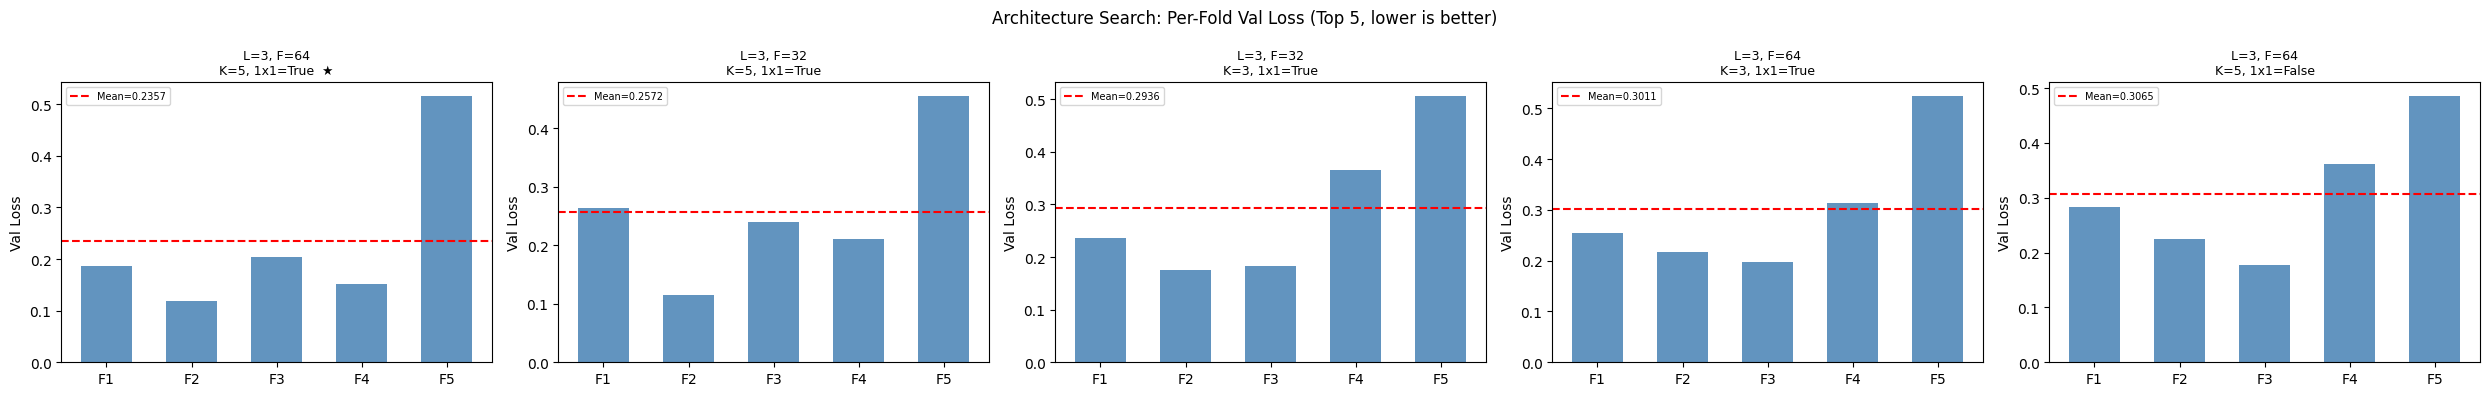

In [ ]:
# Per-fold val_loss bar chart — top 5 architectures by mean val_loss
_arch_keys = ["num_conv_layers", "base_filters", "kernel_size", "use_1x1"]
_top5_arch = sorted(arch_results_A, key=lambda r: r["mean_val_loss"])[:5]

fig, axes = plt.subplots(
    1, len(_top5_arch), figsize=(5 * len(_top5_arch), 4), sharey=False
)
if len(_top5_arch) == 1:
    axes = [axes]

folds = list(range(1, N_FOLDS + 1))
for ax, r in zip(axes, _top5_arch):
    losses = [m["val_loss"] for m in r["fold_metrics"]]
    ax.bar(folds, losses, width=0.6, color="steelblue", alpha=0.85)
    ax.axhline(
        r["mean_val_loss"],
        color="red",
        linestyle="--",
        label=f"Mean={r['mean_val_loss']:.4f}",
    )
    ax.set_xticks(folds)
    ax.set_xticklabels([f"F{f}" for f in folds])
    ax.set_ylabel("Val Loss")
    is_best = all(r[k] == best_arch_A[k] for k in _arch_keys)
    label = (
        f"L={r['num_conv_layers']}, F={r['base_filters']}\n"
        f"K={r['kernel_size']}, 1x1={r['use_1x1']}"
    )
    ax.set_title(label + ("  ★" if is_best else ""), fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle("Architecture Search: Per-Fold Val Loss (Top 5, lower is better)")
plt.tight_layout()
plt.show()

## 5.2 Hyperparameter Search (5-Fold Cross-Validation)

With the best architecture fixed, we tune the remaining hyperparameters using 5-fold stratified cross-validation. Selection criterion: **mean validation loss** (lower is better).

| Axis | Options |
|------|---------|
| `lr` | 1e-3, 5e-4 |
| `dropout` | 0.3, 0.5 |
| `weight_decay` | 1e-4, 1e-2 |

Total: **8 configurations × 5 folds × 100 epochs**

In [ ]:
# ── Phase 2: Hyperparameter Search ───────────────────────────────────────────
# Architecture is fixed to best_arch_A; only lr, dropout, weight_decay vary.
hp_grid = {
    "lr": [1e-3, 5e-4],
    "dropout": [0.3, 0.5],
    "weight_decay": [1e-4, 1e-2],
}

hp_configs = [
    dict(zip(hp_grid.keys(), combo)) for combo in itertools.product(*hp_grid.values())
]

num_epochs_hp = 100
hp_results_A = []

for config in hp_configs:
    print(
        f"\n--- HP: lr={config['lr']:.0e}, dropout={config['dropout']}, "
        f"weight_decay={config['weight_decay']:.0e} ---"
    )
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(
        skf.split(range(len(combined_base)), combined_labels)
    ):
        print(f"  Fold {fold + 1}/{N_FOLDS}...", end=" ", flush=True)

        fold_train_loader = DataLoader(
            Subset(combined_aug, train_idx), batch_size=32, shuffle=True
        )
        fold_val_loader = DataLoader(
            Subset(combined_base, val_idx), batch_size=32, shuffle=False
        )

        model = BaselineCNN(
            num_conv_layers=best_arch_A["num_conv_layers"],
            base_filters=best_arch_A["base_filters"],
            kernel_size=best_arch_A["kernel_size"],
            use_1x1=best_arch_A["use_1x1"],
            dropout_rate=config["dropout"],
        ).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_A)
        optimizer = optim.AdamW(
            model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"]
        )
        warmup = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=5)
        cosine = CosineAnnealingLR(optimizer, T_max=num_epochs_hp - 5, eta_min=1e-6)
        scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[5])

        history = train_model(
            model,
            fold_train_loader,
            fold_val_loader,
            criterion,
            optimizer,
            num_epochs=num_epochs_hp,
            device=device,
            scheduler=scheduler,
        )

        fold_metrics.append(
            {
                "val_loss": history["val_loss"][-1],
                "recall": history["val_recall"][-1],
                "f1": history["val_f1"][-1],
                "history": history,
            }
        )
        print(
            f"val_loss={fold_metrics[-1]['val_loss']:.4f}, recall={fold_metrics[-1]['recall']:.3f}"
        )

    hp_results_A.append(
        {
            **config,
            "mean_val_loss": np.mean([m["val_loss"] for m in fold_metrics]),
            "std_val_loss": np.std([m["val_loss"] for m in fold_metrics]),
            "mean_recall": np.mean([m["recall"] for m in fold_metrics]),
            "mean_f1": np.mean([m["f1"] for m in fold_metrics]),
            "fold_metrics": fold_metrics,
        }
    )
    print(
        f"  => mean val_loss={hp_results_A[-1]['mean_val_loss']:.4f} ± "
        f"{hp_results_A[-1]['std_val_loss']:.4f}"
    )

# Select best HPs: lowest mean 5-fold validation loss
_hp_keys = ["lr", "dropout", "weight_decay"]
best_hp_result_A = min(hp_results_A, key=lambda r: r["mean_val_loss"])
best_hp_A = {k: best_hp_result_A[k] for k in _hp_keys}

# Combine architecture + hyperparameters into final config
best_config_A = {**best_arch_A, **best_hp_A}

print(f"\nBest hyperparameters (Variant A): {best_hp_A}")
print(
    f"  mean val_loss = {best_hp_result_A['mean_val_loss']:.4f} ± "
    f"{best_hp_result_A['std_val_loss']:.4f}"
)
print(f"\nFull best config (Variant A): {best_config_A}")


--- HP: lr=1e-03, dropout=0.3, weight_decay=1e-04 ---
  Fold 1/5... Epoch 5/100 | Train Loss: 0.9116, Acc: 0.5873, Recall: 0.5737, F1: 0.4898 | Val Loss: 0.9026, Acc: 0.5934, Recall: 0.5968, F1: 0.5000 | Grad Norm: 1.0038
Epoch 10/100 | Train Loss: 0.9009, Acc: 0.5901, Recall: 0.5259, F1: 0.4698 | Val Loss: 0.8858, Acc: 0.5000, Recall: 0.9032, F1: 0.5517 | Grad Norm: 1.2058
Epoch 15/100 | Train Loss: 0.7736, Acc: 0.7056, Recall: 0.7131, F1: 0.6259 | Val Loss: 0.7449, Acc: 0.6429, Recall: 0.8226, F1: 0.6108 | Grad Norm: 2.5501
Epoch 20/100 | Train Loss: 0.6042, Acc: 0.7992, Recall: 0.7849, F1: 0.7296 | Val Loss: 0.5642, Acc: 0.8352, Recall: 0.7581, F1: 0.7581 | Grad Norm: 2.5496
Epoch 25/100 | Train Loss: 0.4914, Acc: 0.8514, Recall: 0.8566, F1: 0.7993 | Val Loss: 0.4554, Acc: 0.8132, Recall: 0.9355, F1: 0.7733 | Grad Norm: 2.2962
Epoch 30/100 | Train Loss: 0.3969, Acc: 0.8790, Recall: 0.8765, F1: 0.8333 | Val Loss: 0.3436, Acc: 0.9011, Recall: 0.9355, F1: 0.8657 | Grad Norm: 2.4391
Ep

In [ ]:
# Hyperparameter search results — sorted by mean val_loss ascending
_hp_keys = ["lr", "dropout", "weight_decay"]
df_hp_cv = (
    pd.DataFrame(
        [
            {
                **{k: r[k] for k in _hp_keys},
                "mean_val_loss": r["mean_val_loss"],
                "std_val_loss": r["std_val_loss"],
                "mean_recall": r["mean_recall"],
                "mean_f1": r["mean_f1"],
                "best": all(r[k] == best_hp_A[k] for k in _hp_keys),
            }
            for r in hp_results_A
        ]
    )
    .sort_values("mean_val_loss", ascending=True)
    .reset_index(drop=True)
)
df_hp_cv.index += 1

display(
    df_hp_cv.style.apply(_highlight_best, axis=1)
    .format(
        {
            "lr": "{:.0e}",
            "weight_decay": "{:.0e}",
            "mean_val_loss": "{:.4f}",
            "std_val_loss": "±{:.4f}",
            "mean_recall": "{:.3f}",
            "mean_f1": "{:.3f}",
        }
    )
    .set_caption(
        "Hyperparameter Search — 5-Fold CV val_loss (lower is better, ★ = selected)"
    )
)

print(
    f"\nSelected: lr={best_hp_A['lr']:.0e}, dropout={best_hp_A['dropout']}, "
    f"weight_decay={best_hp_A['weight_decay']:.0e}  "
    f"(mean val_loss={best_hp_result_A['mean_val_loss']:.4f} ± {best_hp_result_A['std_val_loss']:.4f})"
)

,lr,dropout,weight_decay,mean_val_loss,std_val_loss,mean_recall,mean_f1,best
1,5e-04,0.300000,1e-04,0.2282,±0.1251,0.933,0.924,True
2,5e-04,0.500000,1e-02,0.2330,±0.1289,0.939,0.929,False
3,5e-04,0.300000,1e-02,0.2348,±0.1185,0.933,0.920,False
4,1e-03,0.300000,1e-04,0.2454,±0.1228,0.933,0.920,False
5,1e-03,0.300000,1e-02,0.2473,±0.1243,0.946,0.923,False
6,1e-03,0.500000,1e-02,0.2541,±0.1369,0.949,0.924,False
7,5e-04,0.500000,1e-04,0.2552,±0.1431,0.933,0.919,False
8,1e-03,0.500000,1e-04,0.2559,±0.1450,0.936,0.915,False



Selected: lr=5e-04, dropout=0.3, weight_decay=1e-04  (mean val_loss=0.2282 ± 0.1251)


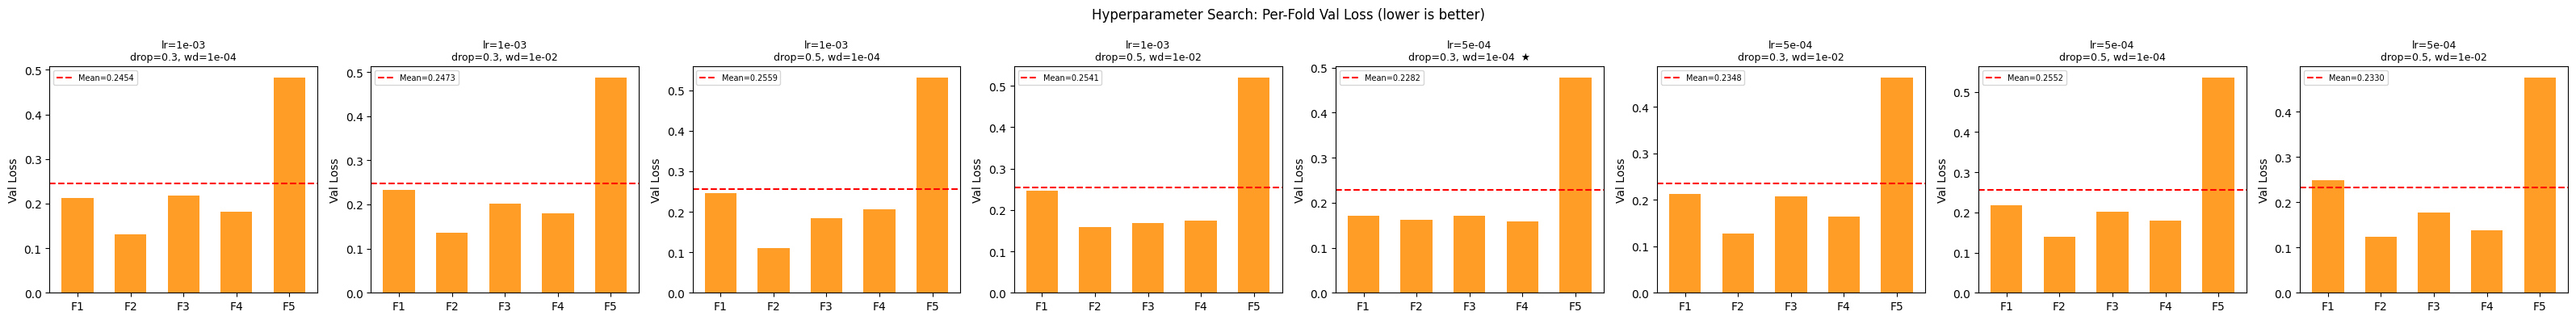

In [ ]:
# Per-fold val_loss bar chart — all 8 hyperparameter configs
fig, axes = plt.subplots(
    1, len(hp_results_A), figsize=(4 * len(hp_results_A), 4), sharey=False
)
if len(hp_results_A) == 1:
    axes = [axes]

_hp_keys = ["lr", "dropout", "weight_decay"]
for ax, r in zip(axes, hp_results_A):
    losses = [m["val_loss"] for m in r["fold_metrics"]]
    ax.bar(folds, losses, width=0.6, color="darkorange", alpha=0.85)
    ax.axhline(
        r["mean_val_loss"],
        color="red",
        linestyle="--",
        label=f"Mean={r['mean_val_loss']:.4f}",
    )
    ax.set_xticks(folds)
    ax.set_xticklabels([f"F{f}" for f in folds])
    ax.set_ylabel("Val Loss")
    is_best = all(r[k] == best_hp_A[k] for k in _hp_keys)
    label = f"lr={r['lr']:.0e}\ndrop={r['dropout']}, wd={r['weight_decay']:.0e}"
    ax.set_title(label + ("  ★" if is_best else ""), fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle("Hyperparameter Search: Per-Fold Val Loss (lower is better)")
plt.tight_layout()
plt.show()

## 5.3 Full Training (train + val)

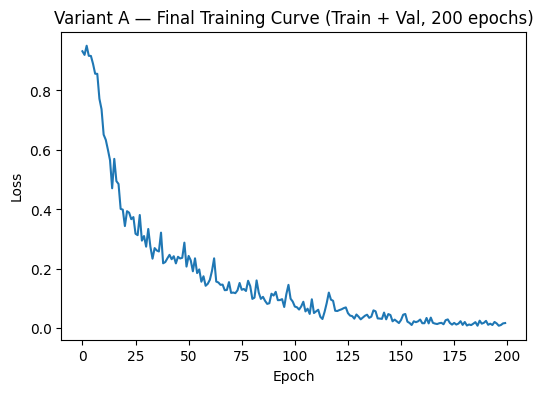

Model A saved!
Model A loaded successfully!


In [ ]:
# Combine train and val for final training
full_train_dataset_A = ConcatDataset([train_dataset, val_dataset])
full_train_loader_A = DataLoader(full_train_dataset_A, batch_size=32, shuffle=True)

num_epochs_final = 200

final_model_A = BaselineCNN(
    num_conv_layers=best_config_A["num_conv_layers"],
    base_filters=best_config_A["base_filters"],
    kernel_size=best_config_A["kernel_size"],
    use_1x1=best_config_A["use_1x1"],
    dropout_rate=best_config_A["dropout"],
).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_A)
optimizer = optim.AdamW(
    final_model_A.parameters(),
    lr=best_config_A["lr"],
    weight_decay=best_config_A["weight_decay"],
)

warmup = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=5)
cosine = CosineAnnealingLR(optimizer, T_max=num_epochs_final - 5, eta_min=1e-6)
scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[5])

final_model_A.train()
train_losses_A = []

for epoch in range(num_epochs_final):
    running_loss = 0.0
    for images, labels in full_train_loader_A:
        images = images.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()
        outputs = final_model_A(images).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(full_train_loader_A.dataset)
    train_losses_A.append(epoch_loss)
    scheduler.step()

plt.figure(figsize=(6, 4))
plt.plot(train_losses_A)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Variant A — Final Training Curve (Train + Val, 200 epochs)")
plt.show()

# Save and reload
torch.save(final_model_A.state_dict(), "baseline_model_A.pth")
print("Model A saved!")

loaded_model_A = BaselineCNN(
    num_conv_layers=best_config_A["num_conv_layers"],
    base_filters=best_config_A["base_filters"],
    kernel_size=best_config_A["kernel_size"],
    use_1x1=best_config_A["use_1x1"],
    dropout_rate=best_config_A["dropout"],
).to(device)
loaded_model_A.load_state_dict(torch.load("baseline_model_A.pth", map_location=device))
loaded_model_A.eval()
print("Model A loaded successfully!")

## 5.4 Evaluation on Test Set

Metrics are reported at the default threshold of **0.5**. Threshold selection for recall=1.0 is performed in Section 8 after both variants have been evaluated.

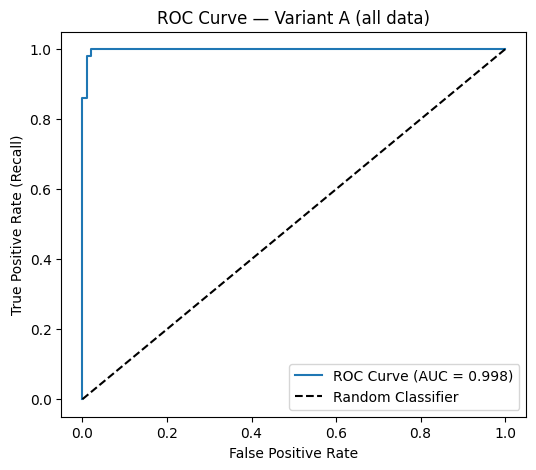

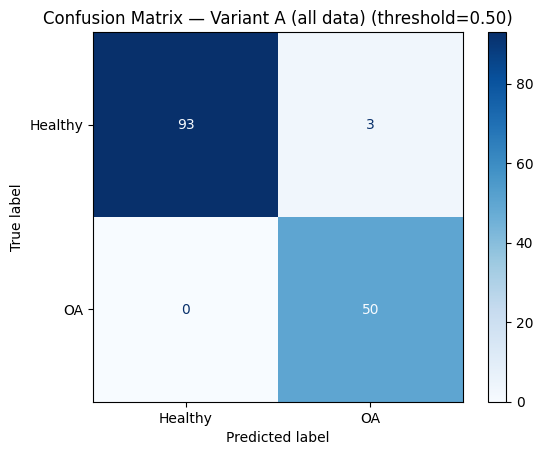


Test Metrics (Variant A (all data)) at threshold=0.50:
  Accuracy : 0.9795
  F1 Score : 0.9709
  Recall   : 1.0000
  Precision: 0.9434


In [ ]:
results_A_test = evaluate_model(
    loaded_model_A, test_loader, device, variant_name="Variant A (all data)"
)

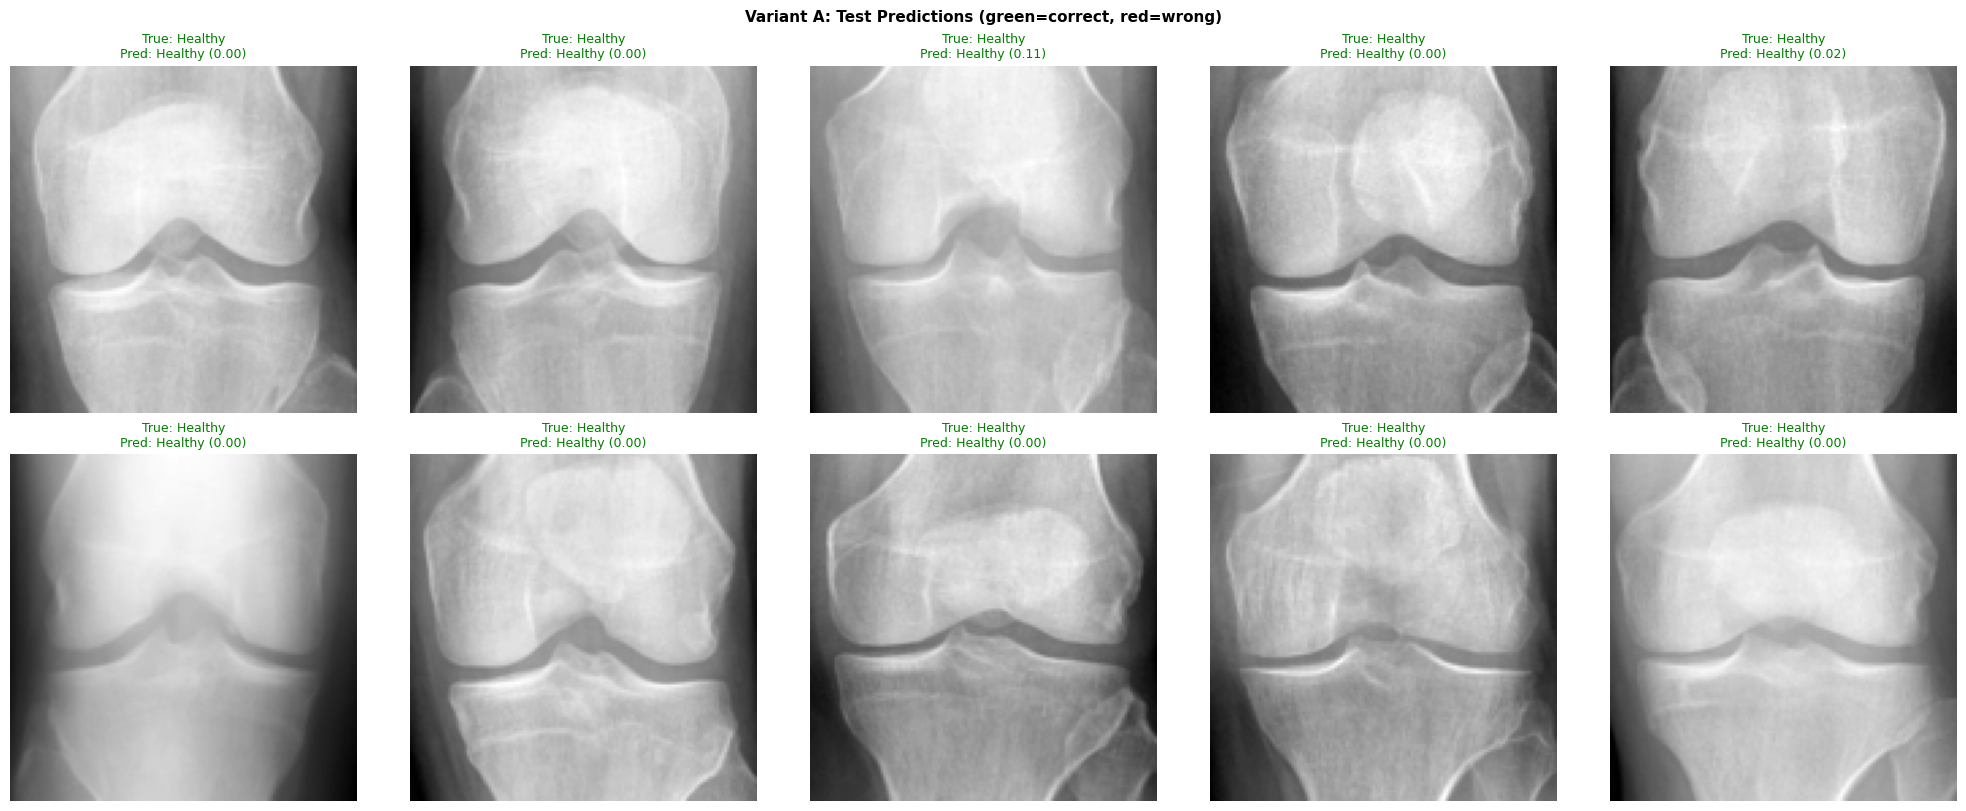

In [ ]:
display_dataset = datasets.ImageFolder(DATA_DIR + "test", transform=MyToTensor())
CLASS_NAMES = ["Healthy", "OA"]

show_images(
    list(range(10)),
    display_dataset,
    results_A_test["all_labels"],
    results_A_test["final_preds"],
    results_A_test["all_probs"],
    CLASS_NAMES,
    title="Variant A: Test Predictions (green=correct, red=wrong)",
)

# 6. Variant B: BaselineCNN without outliers

## 6.1 Hyperparameters

Variant B uses the same best configuration as Variant A (both architecture and hyperparameters). Only the training dataset changes between variants, providing a controlled comparison of the effect of outlier removal.

In [ ]:
# Use the same hyperparameters as Variant A for a fair comparison
# only the dataset changes between variants, not the model or training setup.
best_config_B = best_config_A
print(f"Variant B uses same config as Variant A: {best_config_B}")

# pos_weight for Variant B (calculated from the outlier-filtered training set)
class_counts_B = np.bincount([label for _, label in train_no_outlier_dataset])
pos_weight_B = torch.tensor(
    [class_counts_B[0] / class_counts_B[1]], dtype=torch.float32
).to(device)
print(
    f"Variant B — Healthy: {class_counts_B[0]}, OA: {class_counts_B[1]}, pos_weight_B = {pos_weight_B.item():.4f}"
)

Variant B uses same config as Variant A: {'num_conv_layers': 3, 'base_filters': 64, 'kernel_size': 5, 'use_1x1': True, 'lr': 0.0005, 'dropout': 0.3, 'weight_decay': 0.0001}
Variant B — Healthy: 492, OA: 250, pos_weight_B = 1.9680


## 6.2 Full Training (train + val)

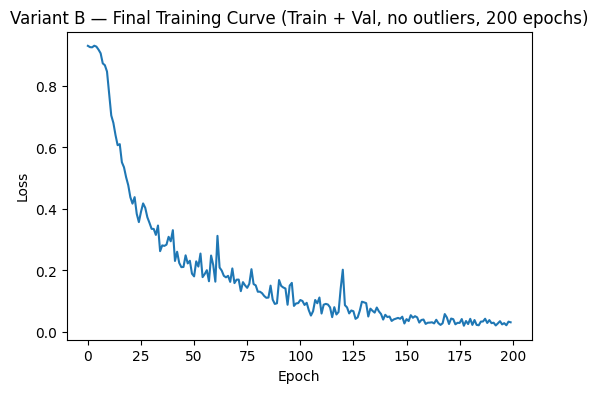

Model B saved!
Model B loaded successfully!


In [ ]:
# Combine no-outlier train and val (with no-outlier normalization)
full_train_dataset_B = ConcatDataset([train_no_outlier_dataset, val_no_outlier_dataset])
full_train_loader_B = DataLoader(full_train_dataset_B, batch_size=32, shuffle=True)

final_model_B = BaselineCNN(
    num_conv_layers=best_config_B["num_conv_layers"],
    base_filters=best_config_B["base_filters"],
    kernel_size=best_config_B["kernel_size"],
    use_1x1=best_config_B["use_1x1"],
    dropout_rate=best_config_B["dropout"],
).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_B)
optimizer = optim.AdamW(
    final_model_B.parameters(),
    lr=best_config_B["lr"],
    weight_decay=best_config_B["weight_decay"],
)

warmup = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=5)
cosine = CosineAnnealingLR(optimizer, T_max=num_epochs_final - 5, eta_min=1e-6)
scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[5])

final_model_B.train()
train_losses_B = []

for epoch in range(num_epochs_final):
    running_loss = 0.0
    for images, labels in full_train_loader_B:
        images = images.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()
        outputs = final_model_B(images).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(full_train_loader_B.dataset)
    train_losses_B.append(epoch_loss)
    scheduler.step()

plt.figure(figsize=(6, 4))
plt.plot(train_losses_B)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Variant B — Final Training Curve (Train + Val, no outliers, 200 epochs)")
plt.show()

# Save and reload
torch.save(final_model_B.state_dict(), "baseline_model_B.pth")
print("Model B saved!")

loaded_model_B = BaselineCNN(
    num_conv_layers=best_config_B["num_conv_layers"],
    base_filters=best_config_B["base_filters"],
    kernel_size=best_config_B["kernel_size"],
    use_1x1=best_config_B["use_1x1"],
    dropout_rate=best_config_B["dropout"],
).to(device)
loaded_model_B.load_state_dict(torch.load("baseline_model_B.pth", map_location=device))
loaded_model_B.eval()
print("Model B loaded successfully!")

## 6.3 Evaluation on Test Set

Metrics are reported at the default threshold of **0.5**, consistent with Variant A.

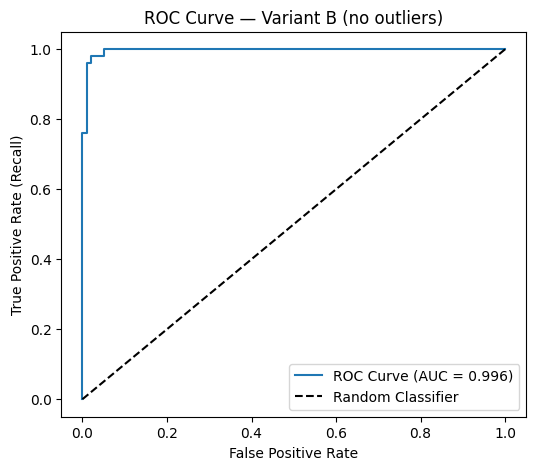

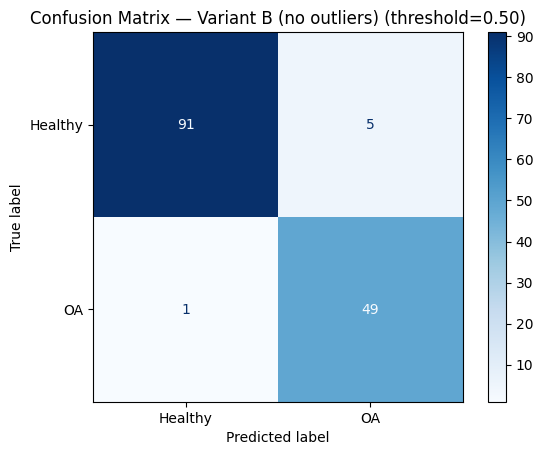


Test Metrics (Variant B (no outliers)) at threshold=0.50:
  Accuracy : 0.9589
  F1 Score : 0.9423
  Recall   : 0.9800
  Precision: 0.9074


In [ ]:
results_B_test = evaluate_model(
    loaded_model_B,
    test_no_outlier_loader,
    device,
    variant_name="Variant B (no outliers)",
)

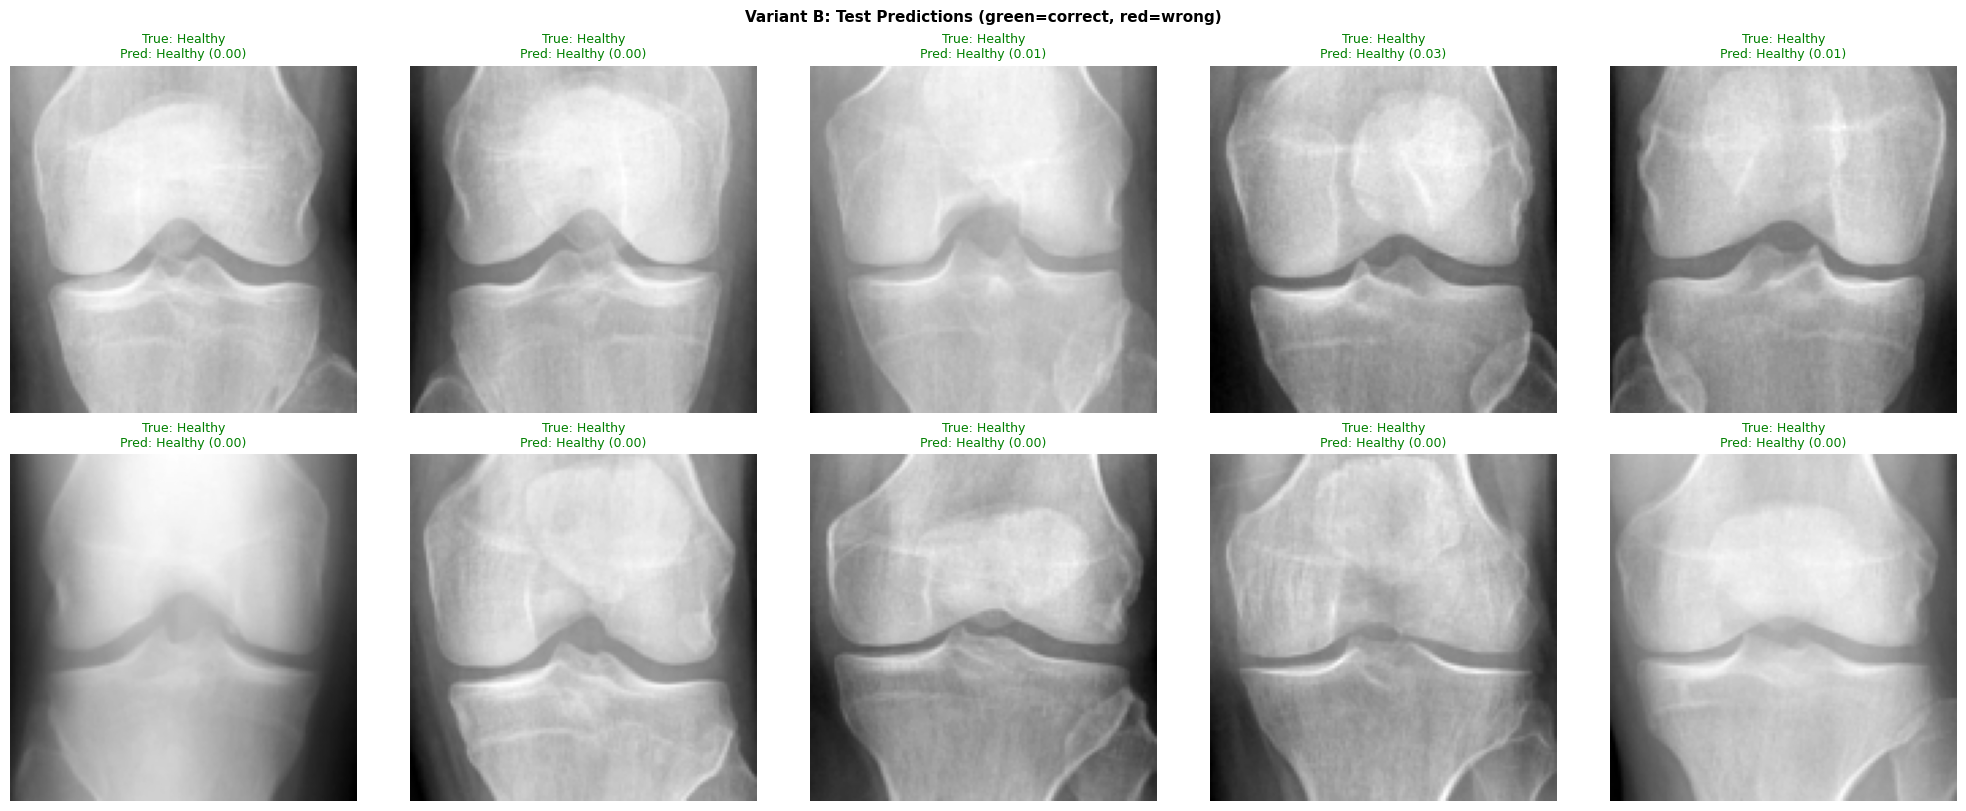

In [ ]:
display_dataset_B = datasets.ImageFolder(DATA_DIR + "test", transform=MyToTensor())

show_images(
    list(range(10)),
    display_dataset_B,
    results_B_test["all_labels"],
    results_B_test["final_preds"],
    results_B_test["all_probs"],
    CLASS_NAMES,
    title="Variant B: Test Predictions (green=correct, red=wrong)",
)

# 7. Comparison & Discussion

In [ ]:
print(f"{'Metric':<20} {'Variant A':>12} {'Variant B':>12}")
print("-" * 46)
print(f"{'AUC':<20} {results_A_test['auc']:>12.4f} {results_B_test['auc']:>12.4f}")
print(
    f"{'Recall':<20} {results_A_test['recall']:>12.4f} {results_B_test['recall']:>12.4f}"
)
print(f"{'F1 Score':<20} {results_A_test['f1']:>12.4f} {results_B_test['f1']:>12.4f}")
print(
    f"{'Accuracy':<20} {results_A_test['accuracy']:>12.4f} {results_B_test['accuracy']:>12.4f}"
)
print(
    f"{'Precision':<20} {results_A_test['precision']:>12.4f} {results_B_test['precision']:>12.4f}"
)
print(
    f"{'Threshold':<20} {results_A_test['threshold']:>12.3f} {results_B_test['threshold']:>12.3f}"
)

Metric                  Variant A    Variant B
----------------------------------------------
AUC                        0.9983       0.9965
Recall                     1.0000       0.9800
F1 Score                   0.9709       0.9423
Accuracy                   0.9795       0.9589
Precision                  0.9434       0.9074
Threshold                   0.500        0.500


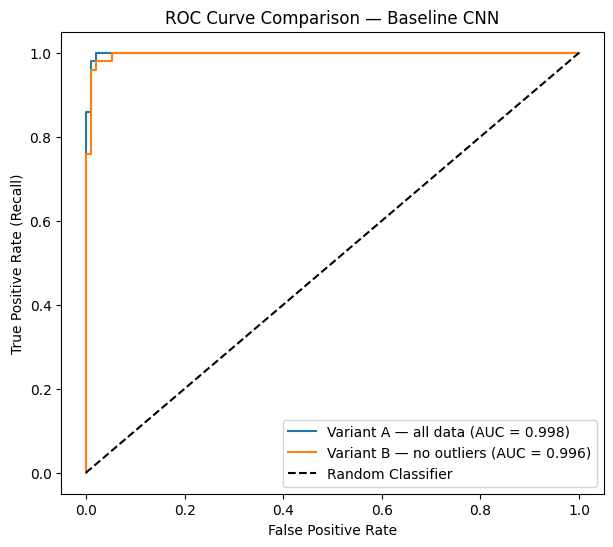

In [ ]:
plt.figure(figsize=(7, 6))
plt.plot(
    results_A_test["fpr"],
    results_A_test["tpr"],
    label=f"Variant A — all data (AUC = {results_A_test['auc']:.3f})",
)
plt.plot(
    results_B_test["fpr"],
    results_B_test["tpr"],
    label=f"Variant B — no outliers (AUC = {results_B_test['auc']:.3f})",
)
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve Comparison — Baseline CNN")
plt.legend()
plt.show()

### Discussion

**Effect of outlier removal:** Compare AUC, recall, and F1 between Variant A and B. Does removing the outlier images improve generalization?

**Effect of pos_weight:** The loss function uses a class-imbalance weight that penalises missed OA cases (false negatives) more heavily, consistent with the clinical screening context where missing an OA diagnosis is more harmful than a false positive.

**Best baseline for downstream comparison:** The winning variant is determined in Section 8 by threshold analysis — both variants' thresholds are moved until recall = 1.0, then the variant with higher precision at that threshold wins.

In [ ]:
# ── Recall=1.0 Threshold Analysis & Variant Selection ────────────────────────
# For each variant, find the highest threshold that still achieves recall == 1.0
# (catches all OA cases). Higher threshold → fewer false positives → better precision.


def find_threshold_for_full_recall(all_labels, all_probs):
    """Return (threshold, precision, recall) at the highest threshold where recall == 1.0."""
    fpr, tpr, thresholds = roc_curve(np.array(all_labels), np.array(all_probs))
    # tpr == recall; find entries where recall is exactly 1.0
    full_recall_mask = tpr == 1.0
    if not np.any(full_recall_mask):
        # No threshold achieves perfect recall; use the one with highest recall
        idx = np.argmax(tpr)
        t = float(thresholds[idx])
    else:
        # Highest threshold where recall == 1.0 (most restrictive, maximises precision)
        t = float(np.max(thresholds[full_recall_mask]))
    preds = (np.array(all_probs) >= t).astype(int)
    prec = float(precision_score(all_labels, preds, zero_division=0))
    rec = float(recall_score(all_labels, preds, zero_division=0))
    return t, prec, rec


threshold_A, precision_A_full, recall_A_full = find_threshold_for_full_recall(
    results_A_test["all_labels"], results_A_test["all_probs"]
)
threshold_B, precision_B_full, recall_B_full = find_threshold_for_full_recall(
    results_B_test["all_labels"], results_B_test["all_probs"]
)

print("Recall = 1.0 threshold analysis:")
print(
    f"  Variant A — threshold: {threshold_A:.4f}, recall: {recall_A_full:.4f}, precision: {precision_A_full:.4f}"
)
print(
    f"  Variant B — threshold: {threshold_B:.4f}, recall: {recall_B_full:.4f}, precision: {precision_B_full:.4f}"
)
print()

if precision_B_full >= precision_A_full:
    best_variant = "B"
    best_threshold = threshold_B
    torch.save(loaded_model_B.state_dict(), "baseline_best.pth")
    print(
        f"Winner: Variant B (precision at recall=1.0: {precision_B_full:.4f} vs {precision_A_full:.4f})"
    )
else:
    best_variant = "A"
    best_threshold = threshold_A
    torch.save(loaded_model_A.state_dict(), "baseline_best.pth")
    print(
        f"Winner: Variant A (precision at recall=1.0: {precision_A_full:.4f} vs {precision_B_full:.4f})"
    )

print(
    f"\nBest baseline: Variant {best_variant} saved as baseline_best.pth (threshold={best_threshold:.4f})"
)

Recall = 1.0 threshold analysis:
  Variant A — threshold: 0.8238, recall: 1.0000, precision: 0.9615
  Variant B — threshold: 0.4717, recall: 1.0000, precision: 0.9091

Winner: Variant A (precision at recall=1.0: 0.9615 vs 0.9091)

Best baseline: Variant A saved as baseline_best.pth (threshold=0.8238)


## 8. Recall = 1.0 Threshold Analysis

For each variant we find the **highest classification threshold at which recall = 1.0** (all OA cases are caught). This is the most restrictive operating point that still guarantees no missed diagnoses.

The variant with the **higher precision** at its recall=1.0 threshold wins — it catches all OA cases while flagging fewer healthy patients unnecessarily.

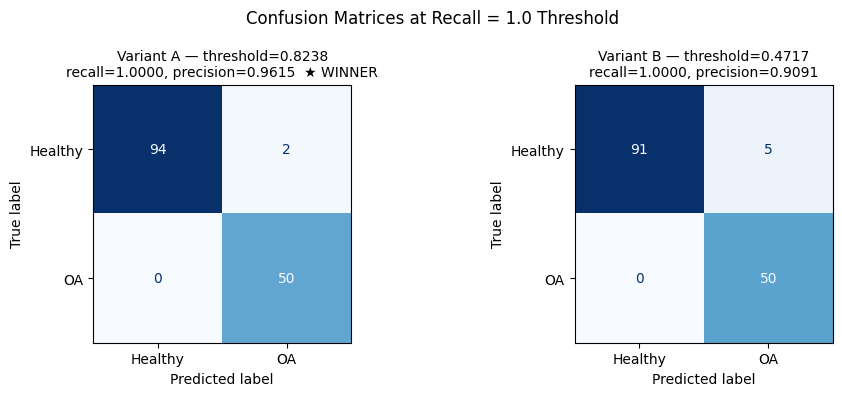

In [ ]:
# Confusion matrices for both variants at their recall=1.0 threshold
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, results, threshold, name in [
    (axes[0], results_A_test, threshold_A, "Variant A"),
    (axes[1], results_B_test, threshold_B, "Variant B"),
]:
    preds = (np.array(results["all_probs"]) >= threshold).astype(int)
    cm = confusion_matrix(results["all_labels"], preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Healthy", "OA"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    prec = precision_score(results["all_labels"], preds, zero_division=0)
    rec = recall_score(results["all_labels"], preds, zero_division=0)
    winner_tag = "  ★ WINNER" if name == f"Variant {best_variant}" else ""
    ax.set_title(
        f"{name} — threshold={threshold:.4f}\n"
        f"recall={rec:.4f}, precision={prec:.4f}{winner_tag}",
        fontsize=10,
    )

plt.suptitle("Confusion Matrices at Recall = 1.0 Threshold", fontsize=12)
plt.tight_layout()
plt.show()

## 9. Final Comparison Summary

Side-by-side comparison of both variants at their respective recall=1.0 thresholds.

In [ ]:
# Summary table: both variants at recall=1.0 threshold
preds_A_full = (np.array(results_A_test["all_probs"]) >= threshold_A).astype(int)
preds_B_full = (np.array(results_B_test["all_probs"]) >= threshold_B).astype(int)

acc_A = accuracy_score(results_A_test["all_labels"], preds_A_full)
f1_A = f1_score(results_A_test["all_labels"], preds_A_full)
acc_B = accuracy_score(results_B_test["all_labels"], preds_B_full)
f1_B = f1_score(results_B_test["all_labels"], preds_B_full)

print(f"{'Metric':<22} {'Variant A':>12} {'Variant B':>12}")
print("-" * 48)
print(f"{'Threshold':<22} {threshold_A:>12.4f} {threshold_B:>12.4f}")
print(f"{'Recall':<22} {recall_A_full:>12.4f} {recall_B_full:>12.4f}")
print(f"{'Precision':<22} {precision_A_full:>12.4f} {precision_B_full:>12.4f}")
print(f"{'F1 Score':<22} {f1_A:>12.4f} {f1_B:>12.4f}")
print(f"{'Accuracy':<22} {acc_A:>12.4f} {acc_B:>12.4f}")
print(f"{'AUC':<22} {results_A_test['auc']:>12.4f} {results_B_test['auc']:>12.4f}")
print("-" * 48)
print(
    f"{'Winner':<22} {'★' if best_variant == 'A' else '':>12} {'★' if best_variant == 'B' else '':>12}"
)

Metric                    Variant A    Variant B
------------------------------------------------
Threshold                    0.8238       0.4717
Recall                       1.0000       1.0000
Precision                    0.9615       0.9091
F1 Score                     0.9804       0.9524
Accuracy                     0.9863       0.9658
AUC                          0.9983       0.9965
------------------------------------------------
Winner                            ★             


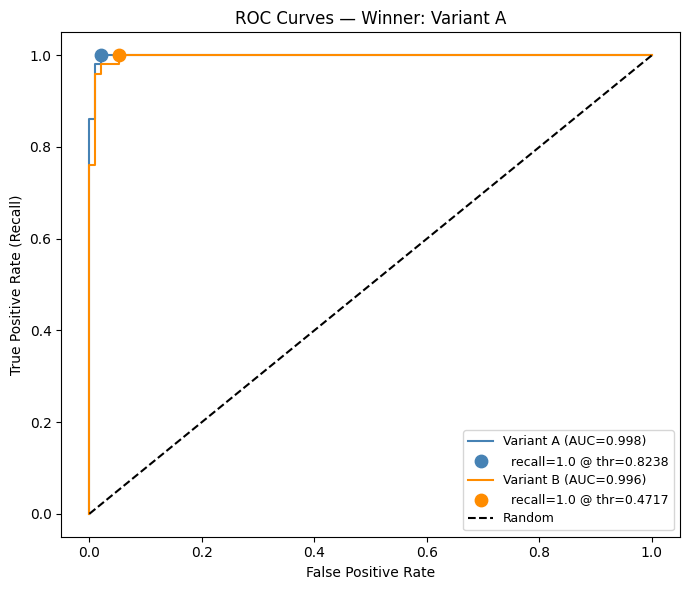

In [ ]:
# ROC curves with recall=1.0 operating point thresholds annotated
fig, ax = plt.subplots(figsize=(7, 6))

for results, threshold, name, color in [
    (results_A_test, threshold_A, "Variant A", "steelblue"),
    (results_B_test, threshold_B, "Variant B", "darkorange"),
]:
    ax.plot(
        results["fpr"],
        results["tpr"],
        label=f"{name} (AUC={results['auc']:.3f})",
        color=color,
    )
    # Find the ROC operating point for this threshold
    preds = (np.array(results["all_probs"]) >= threshold).astype(int)
    tp = np.sum((np.array(results["all_labels"]) == 1) & (preds == 1))
    fn = np.sum((np.array(results["all_labels"]) == 1) & (preds == 0))
    fp = np.sum((np.array(results["all_labels"]) == 0) & (preds == 1))
    tn = np.sum((np.array(results["all_labels"]) == 0) & (preds == 0))
    tpr_pt = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr_pt = fp / (fp + tn) if (fp + tn) > 0 else 0
    ax.scatter(
        [fpr_pt],
        [tpr_pt],
        color=color,
        marker="o",
        s=80,
        zorder=5,
        label=f"  recall=1.0 @ thr={threshold:.4f}",
    )

ax.plot([0, 1], [0, 1], "k--", label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title(f"ROC Curves — Winner: Variant {best_variant}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# 10. Save Results to CSV

In [ ]:
RESULTS_CSV = "../../results/model_comparison.csv"
os.makedirs(os.path.dirname(RESULTS_CSV), exist_ok=True)


def get_run_name(model):
    """Build run name encoding conv block output channels, e.g. BaselineCNN_16_32_64_128_2048."""
    channels = [m.out_channels for m in model.conv_block if isinstance(m, nn.Conv2d)]
    return "BaselineCNN_" + "_".join(map(str, channels))


def results_at_recall1(results):
    """Re-derive metrics at the threshold where recall=1."""
    fpr, tpr, thresholds = results["fpr"], results["tpr"], results["thresholds"]
    threshold, _ = select_threshold_by_recall(fpr, tpr, thresholds, min_recall=1.0)
    preds = (results["all_probs"] >= threshold).astype(int)
    labels = results["all_labels"]
    return {
        **results,
        "threshold": threshold,
        "final_preds": preds,
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds),
        "recall": recall_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
    }


def save_results(model, config, results, variant_name, run_name, csv_path=RESULTS_CSV):
    """Append one row of evaluation metrics + architecture info to a shared CSV."""
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    architecture = str(model)

    row = {
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M"),
        "run_name": run_name,
        "variant": variant_name,
        "architecture": architecture,
        "num_params": num_params,
        "lr": config["lr"],
        "dropout": config["dropout"],
        "weight_decay": config["weight_decay"],
        "auc": round(results["auc"], 4),
        "recall": round(results["recall"], 4),
        "f1": round(results["f1"], 4),
        "accuracy": round(results["accuracy"], 4),
        "precision": round(results["precision"], 4),
        "threshold": round(float(results["threshold"]), 4),
    }

    df_new = pd.DataFrame([row])
    if os.path.exists(csv_path):
        df_existing = pd.read_csv(csv_path)
        df_out = pd.concat([df_existing, df_new], ignore_index=True)
    else:
        df_out = df_new

    df_out.to_csv(csv_path, index=False)
    print(f"Results saved to {csv_path}")
    return df_out


# Re-derive metrics at the threshold where recall=1
results_A_recall1 = results_at_recall1(results_A_test)
results_B_recall1 = results_at_recall1(results_B_test)

print(
    f"Variant A — recall=1 threshold: {results_A_recall1['threshold']:.4f}  recall={results_A_recall1['recall']:.4f}"
)
print(
    f"Variant B — recall=1 threshold: {results_B_recall1['threshold']:.4f}  recall={results_B_recall1['recall']:.4f}"
)

df_results = save_results(
    loaded_model_A,
    best_config_A,
    results_A_recall1,
    variant_name="Variant A (all data)",
    run_name=get_run_name(loaded_model_A),
)
df_results = save_results(
    loaded_model_B,
    best_config_B,
    results_B_recall1,
    variant_name="Variant B (no outliers)",
    run_name=get_run_name(loaded_model_B),
)

print()
display_cols = [
    "timestamp",
    "run_name",
    "variant",
    "num_params",
    "lr",
    "dropout",
    "weight_decay",
    "auc",
    "recall",
    "f1",
    "accuracy",
    "precision",
    "threshold",
]
print(df_results[display_cols].to_string(index=False))

Variant A — recall=1 threshold: 0.8238  recall=1.0000
Variant B — recall=1 threshold: 0.4717  recall=1.0000
Results saved to ../../results/model_comparison.csv
Results saved to ../../results/model_comparison.csv

       timestamp                      run_name                 variant  num_params     lr  dropout  weight_decay    auc  recall     f1  accuracy  precision  threshold
2026-05-02 15:13 BaselineCNN_16_32_64_128_2048    Variant A (all data)      628321 0.0010      0.5           NaN 0.9994    0.98 0.9800    0.9863     0.9800     0.5000
2026-05-02 15:13 BaselineCNN_16_32_64_128_2048 Variant B (no outliers)      628321 0.0010      0.5           NaN 0.9954    0.98 0.9245    0.9452     0.8750     0.5000
2026-05-02 17:45 BaselineCNN_16_32_64_128_2048    Variant A (all data)      628321 0.0010      0.5           NaN 0.9990    0.96 0.9697    0.9795     0.9796     0.5000
2026-05-02 17:45 BaselineCNN_16_32_64_128_2048 Variant B (no outliers)      628321 0.0010      0.5           NaN 0.9935

In [ ]:
# Save probabilities/labels and ROC curve data for the best model (highest AUC)
best_results = results_A_recall1

# Sample-level: one row per image
pd.DataFrame(
    {
        "labels": results_A_recall1["all_labels"],
        "probs": results_A_recall1["all_probs"],
    }
).to_csv("../../results/baseline_best_probs_labels.csv", index=False)

# ROC curve: one row per threshold point
pd.DataFrame(
    {
        "fpr": results_A_recall1["fpr"],
        "tpr": results_A_recall1["tpr"],
        "thresholds": results_A_recall1["thresholds"],
    }
).to_csv("../../results/baseline_best_roc.csv", index=False)

print("Saved: results/baseline_best_probs_labels.csv")
print("Saved: results/baseline_best_roc.csv")

Saved: results/baseline_best_probs_labels.csv
Saved: results/baseline_best_roc.csv
